In [82]:
from viewer.utils import load_env, load_bin, load_probeinterface, format_bytes
from pathlib import Path
from viewer import Ephys, span

import numpy as np
import matplotlib.pyplot as plt
import pynapple as nap

fs = 1250.0
data_path = Path(load_env('/Users/iii9781/viewer/.env')["EPHYS_DATA_PATH"])
data = load_bin(data_path / "eeg" / "eeg.dat")

In [7]:
geometry = load_probeinterface(data_path / "concat" / "probe.json")
stream = Ephys("Probe A", data, geometry, fs=fs, chunk_samples=int(60*fs))

In [11]:
t_a = 100
t_window = 60
t_b = t_a + t_window
channel = 100
span = slice(int(t_a * fs), int(t_b * fs), 1)

block = np.asarray(data[span, channel])
t = np.arange(t_a, t_b, 1/fs)

tsd = nap.Tsd(t=t, d=block)
tsd

Time (s)
----------  ----
100.0       3474
100.0008    3600
100.0016    3678
100.0024    3333
100.0032    3678
100.004     3459
100.0048    3443
...
159.9944    1330
159.9952    1643
159.996     1377
159.9968    1612
159.9976    1612
159.9984    1659
159.9992    1080
dtype: int16, shape: (75000,)

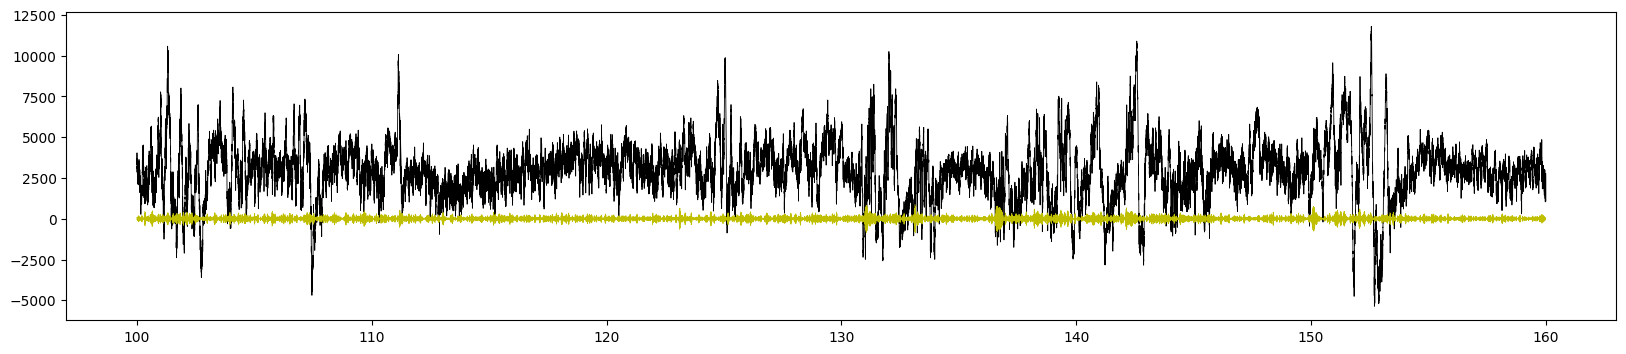

In [12]:
filt = nap.apply_bandpass_filter(tsd, cutoff=(45, 65), fs=fs)
fig, ax = plt.subplots(figsize=(20, 4))
ax.plot(tsd, linewidth=0.6, color='k')
ax.plot(filt, 'y', linewidth=0.3)

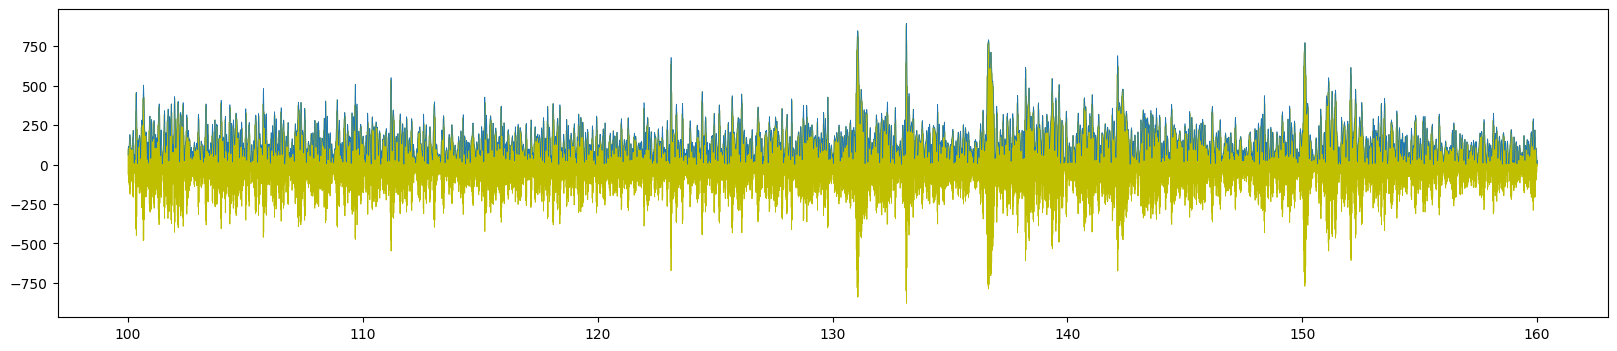

In [13]:
envelope = nap.compute_hilbert_envelope(filt)
fig, ax = plt.subplots(figsize=(20, 4))
ax.plot(filt, 'y', linewidth=0.6)
ax.plot(envelope, linewidth=0.5 )

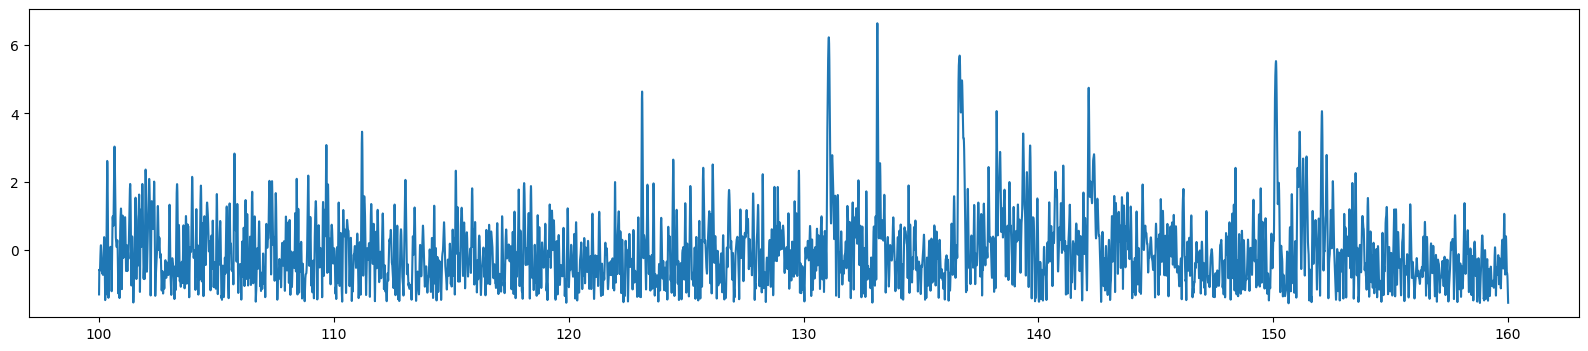

In [19]:
smoothing_bins = 10
window = np.ones(smoothing_bins) / smoothing_bins

smoothed = envelope.convolve(window)
zscored_smoothed = (smoothed - smoothed.mean()) / smoothed.std()


fig, ax = plt.subplots(figsize=(20, 4))
# ax.plot(filt, 'y', linewidth=0.6)
# ax.plot(envelope, linewidth=0.5 )
ax.plot(zscored_smoothed)

In [42]:
threshold = 3.5
gamma_events = zscored_smoothed.threshold(threshold, method="above")
gamma_eps = gamma_events.time_support
gamma_eps = gamma_eps.drop_short_intervals(0.01, time_units="s") # 10 ms
gamma_eps = gamma_eps.drop_long_intervals(0.3, time_units="s")
gamma_eps = gamma_eps.merge_close_intervals(0.02, time_units="s")
gamma_eps

  index    start      end
      0  123.104  123.142
      1  131.011  131.122
      2  133.113  133.169
      3  136.58   136.789
      4  138.208  138.232
      5  142.116  142.16
      6  150.058  150.155
      7  152.051  152.088
shape: (8, 2), time unit: sec.

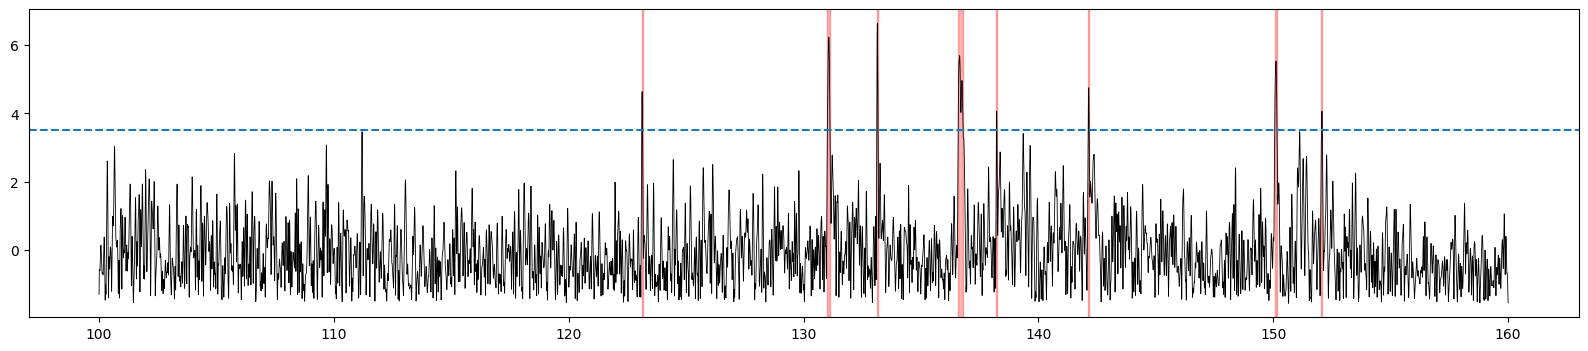

In [44]:
fig, ax = plt.subplots(figsize=(20, 4))
ax.plot(zscored_smoothed, linewidth=0.6, color='k')
ax.axhline(threshold, linestyle='--')

for s, e in gamma_eps.values:
    ax.axvspan(s, e, alpha=0.3, color='red')

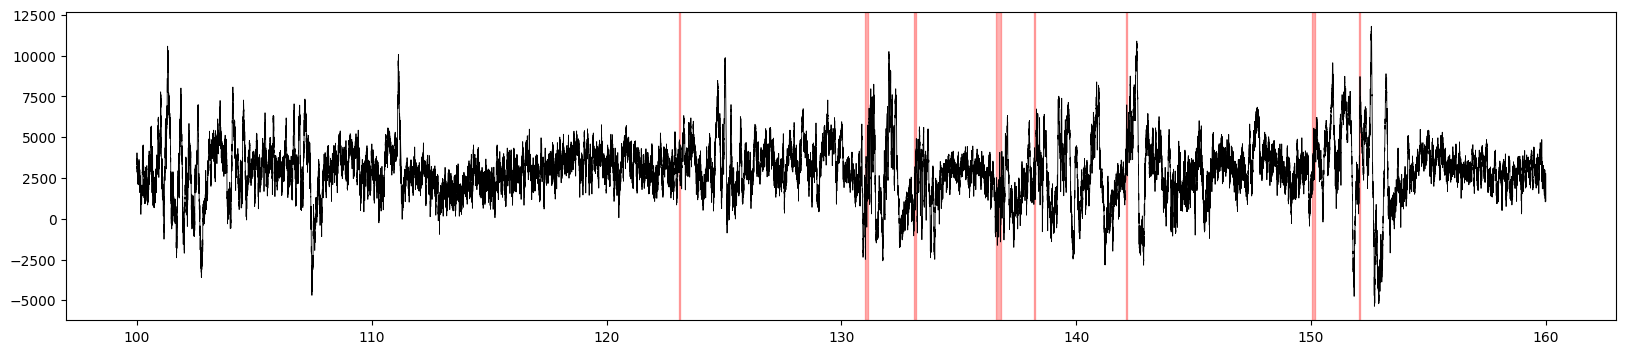

In [48]:
fig, ax = plt.subplots(figsize=(20, 4))
ax.plot(tsd, linewidth=0.6, color='k')
for s, e in gamma_eps.values:
    ax.axvspan(s, e, alpha=0.3, color='red')

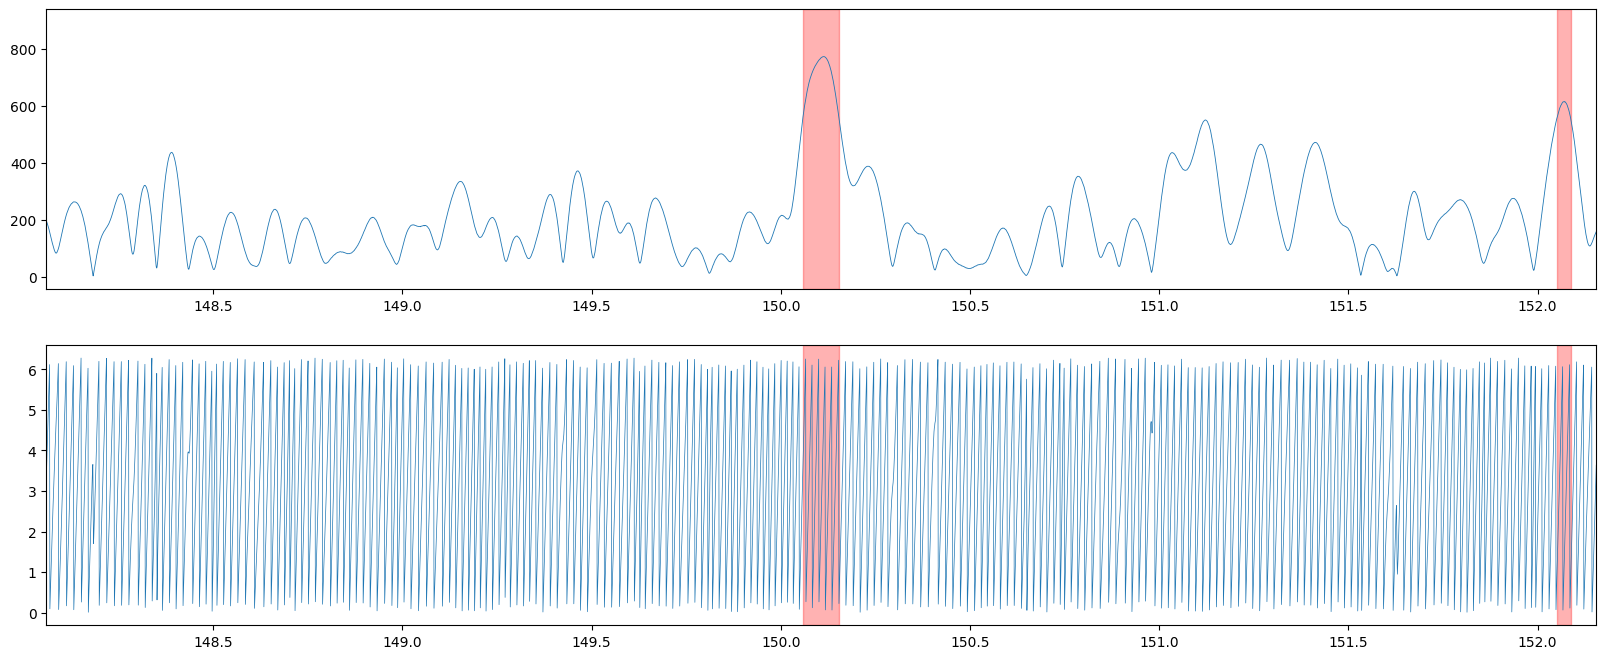

In [77]:
gphase = nap.compute_hilbert_phase(filt)
envelope = nap.compute_hilbert_envelope(filt)

fig, axs = plt.subplots(2, 1, figsize=(20, 8))
axs[0].plot(envelope, linewidth=0.6)
axs[1].plot(gphase, linewidth=0.5 )

for s, e in gamma_eps.values:
    for ax in axs:
        ax.axvspan(s, e, alpha=0.3, color='red')

ep = gamma_eps[6]
left_pad = 2
right_pad = 2

for ax in axs:
    ax.set_xlim(ep['start'] - left_pad, ep['end'] + right_pad)